# Colab Session: siamese-session
Generated from colab-cli history log.

**Session Created**: 2026-08-13 09:40:14
- Endpoint: `gpu-t4-s-kkb-usw1b2-mza31xc6lys`
- Hardware: `T4`

In [ ]:
import os, json, subprocess
os.makedirs("/root/.kaggle", exist_ok=True)
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
creds = {"username":"adithyaekanayaka","key":"55a2efa2e26c74959a9185e10cc8e35e"}
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(creds, f)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(creds, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

# Write local kaggle.json in working dir as well so Option B in notebook succeeds
with open("kaggle.json", "w") as f:
    json.dump(creds, f)
os.chmod("kaggle.json", 0o600)

print("✅ kaggle.json set up on Colab VM!")

subprocess.run(["pip", "install", "-q", "kaggle"])
res = subprocess.run(["kaggle", "datasets", "list", "-s", "att-database-of-faces"], capture_output=True, text=True)
print("Kaggle Dataset Search Output:\n", res.stdout)


✅ kaggle.json set up on Colab VM!


Kaggle Dataset Search Output:
ref                             title                         size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------  ----------------------  ----------  --------------------------  -------------  ---------  ---------------  
kasikrit/att-database-of-faces  AT&T Database of Faces     3781724  2019-12-17 02:47:06.897000          28011        164  0.375            



In [ ]:
# Install the Kaggle library to download datasets
!pip install kaggle -q

import os

# Create the .kaggle directory where credentials are stored
os.makedirs('/root/.kaggle', exist_ok=True)

print('✅ Kaggle installed and directory created!')

✅ Kaggle installed and directory created!


In [ ]:
import shutil
import os

# ── Option A: Google Colab (uncomment below) ──────────────
# from google.colab import files
# uploaded = files.upload()  # Opens file picker → select kaggle.json

# ── Option B: kaggle.json already in current directory ────
if os.path.exists('kaggle.json'):
    shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
    print('✅ kaggle.json copied to /root/.kaggle/')
elif os.path.exists('/root/.kaggle/kaggle.json'):
    print('✅ kaggle.json already in place!')
else:
    print('❌ Please upload your kaggle.json file!')

# Set secure permissions (required by Kaggle API)
!chmod 600 /root/.kaggle/kaggle.json
print('✅ Permissions set correctly!')

✅ kaggle.json copied to /root/.kaggle/


✅ Permissions set correctly!


In [ ]:
# Download and unzip the dataset
!kaggle datasets download -d kasikrit/att-database-of-faces \
                          -p ./data \
                          --unzip \
                          -q

print('✅ Dataset downloaded!')
print('\n📁 Directory structure:')
!find ./data -type d | head -20

Dataset URL: https://www.kaggle.com/datasets/kasikrit/att-database-of-faces
License(s): unknown


✅ Dataset downloaded!

📁 Directory structure:
./data
./data/s19
./data/s35
./data/s4
./data/s16
./data/s29
./data/s27
./data/s9
./data/s18
./data/s30
./data/s5
./data/s31
./data/s22
./data/s14
./data/s32
./data/s10
./data/s7
./data/s17
./data/s11
./data/s15


In [ ]:
# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Data Processing
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.manifold import TSNE

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import os, random, itertools, warnings, glob
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ Libraries imported!')
print(f'   TensorFlow version: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'   GPU: {gpus if gpus else "Not available (CPU mode)"}')

✅ Libraries imported!
   TensorFlow version: 2.20.0
   GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
class Config:
    """Central configuration — change values here to experiment!"""
    # Image
    IMG_HEIGHT   = 112
    IMG_WIDTH    = 92
    IMG_CHANNELS = 1        # 1=grayscale, 3=RGB
    # Dataset
    NUM_SUBJECTS            = 40
    IMGS_PER_SUBJECT        = 10
    POSITIVE_PAIRS_PER_SUBJECT = 20
    NEGATIVE_PAIRS_PER_SUBJECT = 20
    # Training
    BATCH_SIZE    = 32
    EPOCHS        = 50
    LEARNING_RATE = 0.0001
    # Split
    TEST_SIZE       = 0.15
    VALIDATION_SIZE = 0.15
    # Model
    EMBEDDING_DIM = 128
    MARGIN        = 1.0
    # Paths
    DATA_PATH  = './data/att_faces'
    MODEL_PATH = './best_model.h5'

cfg = Config()
print('✅ Configuration ready!')
print(f'   Image shape:      {cfg.IMG_HEIGHT}x{cfg.IMG_WIDTH}x{cfg.IMG_CHANNELS}')
print(f'   Embedding dim:    {cfg.EMBEDDING_DIM}')
print(f'   Contrastive margin: {cfg.MARGIN}')

✅ Configuration ready!
   Image shape:      112x92x1
   Embedding dim:    128
   Contrastive margin: 1.0


In [ ]:
def load_att_dataset(data_path, img_height, img_width):
    """
    Load all images from the AT&T face database.
    Structure: att_faces/s1/1.pgm, att_faces/s1/2.pgm, ...
    Returns: images (N,H,W,C), labels (N,)
    """
    images, labels = [], []
    for root, dirs, files in os.walk(data_path):
        dirs.sort()
        pgm_files = [f for f in files if f.endswith('.pgm')]
        if pgm_files:
            folder_name = os.path.basename(root)
            subject_id  = int(folder_name[1:]) - 1  # 's1' -> 0
            for img_file in sorted(pgm_files):
                img_path  = os.path.join(root, img_file)
                img       = Image.open(img_path).convert('L')
                img       = img.resize((img_width, img_height), Image.LANCZOS)
                img_array = np.array(img, dtype=np.float32)
                img_array = np.expand_dims(img_array, axis=-1)  # (H,W) -> (H,W,1)
                images.append(img_array)
                labels.append(subject_id)
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)


print('📂 Loading dataset...')
images, labels = load_att_dataset(cfg.DATA_PATH, cfg.IMG_HEIGHT, cfg.IMG_WIDTH)

# Normalize pixel values to [0, 1]
images = images / 255.0

print(f'\n✅ Dataset loaded!')
print(f'   Images shape: {images.shape}')
print(f'   Labels range: {labels.min()} to {labels.max()}')
print(f'   Pixel range:  {images.min():.2f} to {images.max():.2f}')

📂 Loading dataset...

✅ Dataset loaded!
   Images shape: (0,)


ValueError: zero-size array to reduction operation minimum which has no identity

ValueError: Sample larger than population or is negative

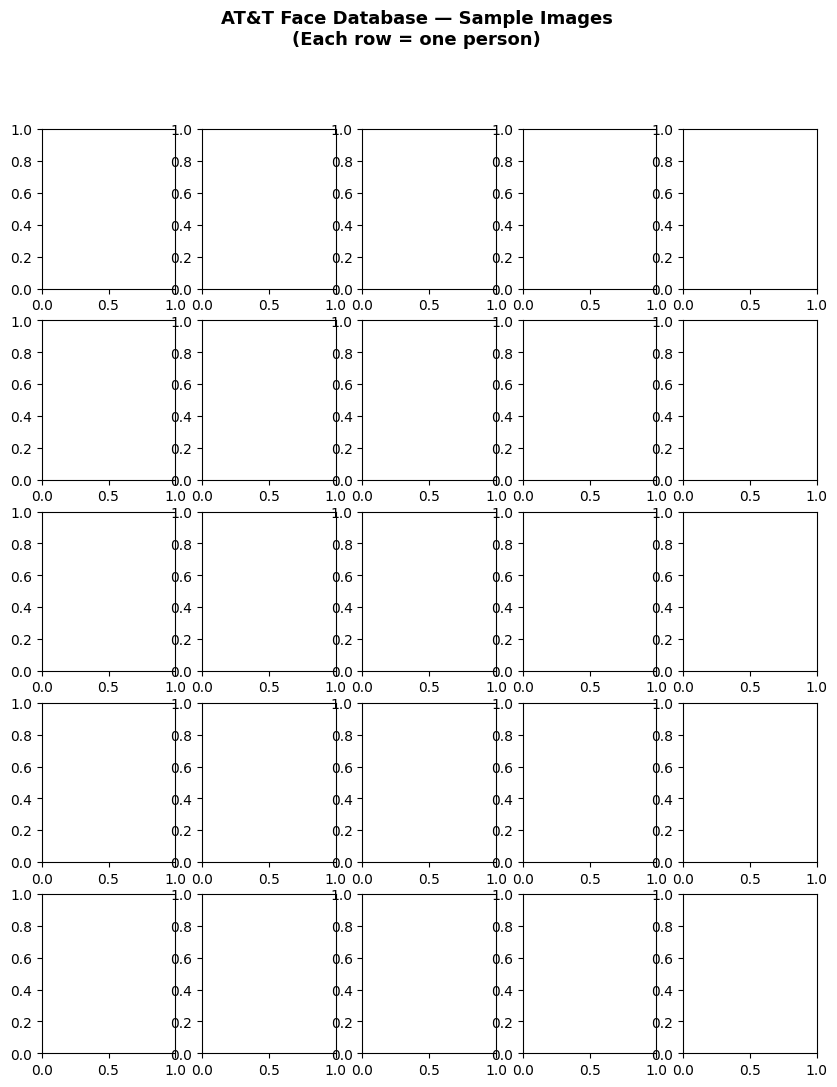

In [ ]:
fig, axes = plt.subplots(5, 5, figsize=(10, 12))
fig.suptitle('AT&T Face Database — Sample Images\n(Each row = one person)',
             fontsize=13, fontweight='bold')

subject_ids = random.sample(range(cfg.NUM_SUBJECTS), 5)

for row, subject_id in enumerate(subject_ids):
    subject_indices = list(np.where(labels == subject_id)[0])
    selected = random.sample(subject_indices, 5)
    for col, img_idx in enumerate(selected):
        ax = axes[row, col]
        ax.imshow(images[img_idx].squeeze(), cmap='gray')
        ax.set_title(f'Subject {subject_id+1}', fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def create_pairs(images, labels, positive_pairs, negative_pairs, seed=42):
    """
    Generate positive (same person) and negative (different person) pairs.
    Labels: 0 = same, 1 = different
    """
    random.seed(seed)
    pair_images_1, pair_images_2, pair_labels = [], [], []
    unique_subjects   = np.unique(labels)
    subject_to_indices = {s: list(np.where(labels == s)[0]) for s in unique_subjects}

    # POSITIVE pairs (same person)
    for subject_id in unique_subjects:
        indices = subject_to_indices[subject_id]
        all_combos = list(itertools.combinations(indices, 2))
        selected   = random.sample(all_combos, min(positive_pairs, len(all_combos)))
        for idx1, idx2 in selected:
            pair_images_1.append(images[idx1])
            pair_images_2.append(images[idx2])
            pair_labels.append(0)  # 0 = same

    # NEGATIVE pairs (different people)
    for subject_id in unique_subjects:
        other_subjects = [s for s in unique_subjects if s != subject_id]
        for _ in range(negative_pairs):
            idx1         = random.choice(subject_to_indices[subject_id])
            other_subject = random.choice(other_subjects)
            idx2         = random.choice(subject_to_indices[other_subject])
            pair_images_1.append(images[idx1])
            pair_images_2.append(images[idx2])
            pair_labels.append(1)  # 1 = different

    # Convert and shuffle
    p1  = np.array(pair_images_1, dtype=np.float32)
    p2  = np.array(pair_images_2, dtype=np.float32)
    lbl = np.array(pair_labels,   dtype=np.float32)
    idx = np.random.permutation(len(lbl))
    return p1[idx], p2[idx], lbl[idx]


print('🔄 Creating pairs...')
img1, img2, pair_labels = create_pairs(
    images, labels,
    cfg.POSITIVE_PAIRS_PER_SUBJECT,
    cfg.NEGATIVE_PAIRS_PER_SUBJECT,
    seed=SEED
)

same = (pair_labels == 0).sum()
diff = (pair_labels == 1).sum()
print(f'\n✅ Pairs created: {len(pair_labels)} total')
print(f'   Positive (same):    {same} ({same/len(pair_labels)*100:.1f}%)')
print(f'   Negative (different): {diff} ({diff/len(pair_labels)*100:.1f}%)')

🔄 Creating pairs...

✅ Pairs created: 0 total
   Positive (same):    0 (nan%)
   Negative (different): 0 (nan%)


In [ ]:
# First split: hold out TEST set
img1_tv, img1_test, img2_tv, img2_test, y_tv, y_test = train_test_split(
    img1, img2, pair_labels,
    test_size=cfg.TEST_SIZE, random_state=SEED, stratify=pair_labels
)

# Second split: separate VALIDATION from training
img1_train, img1_val, img2_train, img2_val, y_train, y_val = train_test_split(
    img1_tv, img2_tv, y_tv,
    test_size=cfg.VALIDATION_SIZE, random_state=SEED, stratify=y_tv
)

print('✅ Data split complete!')
print(f'   Train:      {len(y_train):,} pairs')
print(f'   Validation: {len(y_val):,} pairs')
print(f'   Test:       {len(y_test):,} pairs')

ValueError: With n_samples=0, test_size=0.15 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
def build_encoder(input_shape, embedding_dim):
    """CNN encoder: image → L2-normalized embedding vector."""
    inputs = keras.Input(shape=input_shape, name='encoder_input')

    def conv_block(x, filters, name, dropout=0.2):
        x = layers.Conv2D(filters, (3,3), padding='same', name=f'conv_{name}')(x)
        x = layers.BatchNormalization(name=f'bn_{name}')(x)
        x = layers.Activation('relu', name=f'relu_{name}')(x)
        x = layers.MaxPooling2D((2,2), name=f'pool_{name}')(x)
        x = layers.Dropout(dropout, name=f'drop_{name}')(x)
        return x

    x = conv_block(inputs,  64,  '1', dropout=0.2)
    x = conv_block(x,      128,  '2', dropout=0.2)
    x = conv_block(x,      256,  '3', dropout=0.3)
    x = conv_block(x,      256,  '4', dropout=0.3)

    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(512, name='dense1')(x)
    x = layers.BatchNormalization(name='bn5')(x)
    x = layers.Activation('relu', name='relu5')(x)
    x = layers.Dropout(0.4, name='drop5')(x)
    x = layers.Dense(embedding_dim, name='embedding')(x)

    # L2 normalize: project embeddings onto unit hypersphere
    embeddings = layers.Lambda(
        lambda t: tf.nn.l2_normalize(t, axis=1),
        name='l2_normalize'
    )(x)

    return Model(inputs, embeddings, name='encoder')


input_shape = (cfg.IMG_HEIGHT, cfg.IMG_WIDTH, cfg.IMG_CHANNELS)
encoder     = build_encoder(input_shape, cfg.EMBEDDING_DIM)

print('✅ Encoder built!')
encoder.summary()

✅ Encoder built!


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 112, 92, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 112, 92, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 112, 92, 64)    │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 112, 92, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 56, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 56, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 56, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 56, 46, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 56, 46, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 28, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 28, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 28, 23, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 28, 23, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 28, 23, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 14, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 14, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4 (Conv2D)                 │ (None, 14, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 14, 11, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_4 (Activation)             │ (None, 14, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_4 (MaxPooling2D)           │ (None, 7, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_4 (Dropout)                │ (None, 7, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu5 (Activation)              │ (None, 512)            │             

 Total params: 1,161,856 (4.43 MB)

 Trainable params: 1,159,424 (4.42 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [ ]:
def build_siamese_network(encoder, input_shape):
    """Connect two shared encoders with a distance computation layer."""
    input_a = keras.Input(shape=input_shape, name='input_image_A')
    input_b = keras.Input(shape=input_shape, name='input_image_B')

    # SHARED encoder processes both inputs
    embedding_a = encoder(input_a)
    embedding_b = encoder(input_b)

    # Euclidean distance between embeddings
    distance = layers.Lambda(
        lambda embs: tf.sqrt(
            tf.reduce_sum(tf.square(embs[0] - embs[1]), axis=1, keepdims=True)
        ),
        name='euclidean_distance'
    )([embedding_a, embedding_b])

    return Model(inputs=[input_a, input_b], outputs=distance,
                 name='siamese_network')


siamese_model = build_siamese_network(encoder, input_shape)
print('✅ Siamese Network built!')
siamese_model.summary()

✅ Siamese Network built!


Model: "siamese_network"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image_A       │ (None, 112, 92,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_image_B       │ (None, 112, 92,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ (None, 128)       │  1,161,856 │ input_image_A[0]… │
│ (Functional)        │                   │            │ input_image_B[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ euclidean_distance  │ (None, 1)         │          0 │ encoder[0][0],    │
│ (Lambda)            │                   │            │ encoder[1][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,161,856 (4.43 MB)

 Trainable params: 1,159,424 (4.42 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [ ]:
def contrastive_loss(margin=1.0):
    """Returns contrastive loss function with given margin."""
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        similar_loss    = (1 - y_true) * tf.square(y_pred)
        dissimilar_loss = y_true * tf.square(tf.maximum(0.0, margin - y_pred))
        return tf.reduce_mean(similar_loss + dissimilar_loss) / 2.0
    return loss


def accuracy_with_threshold(threshold=0.5):
    """Accuracy metric: distance > threshold -> different (1), else same (0)."""
    def accuracy(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        preds  = tf.cast(y_pred > threshold, tf.float32)
        return tf.reduce_mean(tf.cast(tf.equal(preds, y_true), tf.float32))
    accuracy.__name__ = f'accuracy_t{threshold}'
    return accuracy


# Compile
siamese_model.compile(
    optimizer=Adam(learning_rate=cfg.LEARNING_RATE),
    loss=contrastive_loss(margin=cfg.MARGIN),
    metrics=[accuracy_with_threshold(threshold=0.5)]
)

print('✅ Model compiled!')
print(f'   Optimizer: Adam  |  LR: {cfg.LEARNING_RATE}')
print(f'   Loss: Contrastive (margin={cfg.MARGIN})')

✅ Model compiled!
   Optimizer: Adam  |  LR: 0.0001
   Loss: Contrastive (margin=1.0)


In [ ]:
callbacks = [
    ModelCheckpoint(cfg.MODEL_PATH, monitor='val_loss',
                    save_best_only=True, mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-7, verbose=1)
]

print('🚀 Training started...')
history = siamese_model.fit(
    x=[img1_train, img2_train],
    y=y_train,
    batch_size=cfg.BATCH_SIZE,
    epochs=cfg.EPOCHS,
    validation_data=([img1_val, img2_val], y_val),
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

print(f'\n✅ Training complete!')
print(f'   Epochs run:    {len(history.history["loss"])}')
print(f'   Best val_loss: {min(history.history["val_loss"]):.4f}')

🚀 Training started...


NameError: name 'img1_train' is not defined

In [ ]:
epochs_range = range(1, len(history.history['loss']) + 1)
metric_key   = [k for k in history.history if 'accuracy' in k and 'val' not in k][0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs_range, history.history['loss'],     'b-o', ms=4, label='Train Loss')
ax1.plot(epochs_range, history.history['val_loss'], 'r-o', ms=4, label='Val Loss')
best_ep = np.argmin(history.history['val_loss']) + 1
ax1.axvline(x=best_ep, color='green', ls='--', label=f'Best Epoch: {best_ep}')
ax1.set_title('Contrastive Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, history.history[metric_key],           'b-o', ms=4, label='Train Acc')
ax2.plot(epochs_range, history.history['val_' + metric_key], 'r-o', ms=4, label='Val Acc')
ax2.axhline(y=0.5, color='gray', ls=':', label='Random (50%)')
ax2.set_title('Accuracy', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3); ax2.set_ylim([0, 1.05])

plt.suptitle('Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

NameError: name 'history' is not defined

In [ ]:
# Get distances for all test pairs
distances = siamese_model.predict([img1_test, img2_test],
                                   batch_size=cfg.BATCH_SIZE).squeeze()

# Find optimal threshold
thresholds  = np.arange(0.0, 2.0, 0.01)
best_thresh = 0.5
best_acc    = 0.0
for t in thresholds:
    preds = (distances > t).astype(int)
    acc   = (preds == y_test.astype(int)).mean()
    if acc > best_acc:
        best_acc, best_thresh = acc, t

predictions = (distances > best_thresh).astype(int)
true_labels  = y_test.astype(int)

print(f'Optimal threshold: {best_thresh:.3f}')
print(f'Test accuracy:     {best_acc:.4f} ({best_acc*100:.2f}%)')
print('\n' + '='*50)
print(classification_report(true_labels, predictions,
      target_names=['Same (0)', 'Different (1)']))

# Confusion Matrix
cm = confusion_matrix(true_labels, predictions)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Pred: Same', 'Pred: Different'],
            yticklabels=['True: Same', 'True: Different'])
ax1.set_title('Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(true_labels, distances)
roc_auc     = auc(fpr, tpr)
ax2.plot(fpr, tpr, 'b-', lw=3, label=f'AUC = {roc_auc:.4f}')
ax2.plot([0,1],[0,1],'r--', lw=2, label='Random')
ax2.fill_between(fpr, tpr, alpha=0.2)
ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'img1_test' is not defined

In [ ]:
print('Extracting embeddings...')
all_embeddings = encoder.predict(images, batch_size=cfg.BATCH_SIZE, verbose=1)

print('Running t-SNE (may take a minute)...')
tsne = TSNE(n_components=2, perplexity=15, n_iter=1000,
            random_state=SEED, learning_rate='auto')
embeddings_2d = tsne.fit_transform(all_embeddings)

plt.figure(figsize=(12, 8))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for i in range(10):
    idx = labels == i
    plt.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1],
                c=[colors[i]], label=f'S{i+1}', s=100,
                alpha=0.8, edgecolors='white', linewidth=0.5)

for i in range(10, cfg.NUM_SUBJECTS):
    idx = labels == i
    plt.scatter(embeddings_2d[idx,0], embeddings_2d[idx,1],
                c='lightgray', s=50, alpha=0.3)

plt.title('t-SNE of Learned Embeddings\n(Colored = first 10 subjects)',
          fontsize=13, fontweight='bold')
plt.xlabel('t-SNE Dim 1'); plt.ylabel('t-SNE Dim 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Extracting embeddings...


ValueError: math domain error

In [ ]:
same_dist = distances[y_test == 0]
diff_dist = distances[y_test == 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(same_dist, bins=30, alpha=0.7, color='green',
         label=f'Same (n={len(same_dist)})', density=True)
ax1.hist(diff_dist, bins=30, alpha=0.7, color='red',
         label=f'Different (n={len(diff_dist)})', density=True)
ax1.axvline(x=best_thresh, color='blue', ls='--', lw=2,
            label=f'Threshold={best_thresh:.3f}')
ax1.set_xlabel('Distance'); ax1.set_ylabel('Density')
ax1.set_title('Distance Distributions', fontweight='bold')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.boxplot([same_dist, diff_dist],
            labels=['Same Person', 'Different Person'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
ax2.axhline(y=best_thresh, color='red', ls='--', lw=2,
            label=f'Threshold={best_thresh:.3f}')
ax2.set_ylabel('Distance')
ax2.set_title('Distance Box Plot', fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Same person  — mean: {same_dist.mean():.4f}, std: {same_dist.std():.4f}')
print(f'Diff person  — mean: {diff_dist.mean():.4f}, std: {diff_dist.std():.4f}')
print(f'Separation ratio: {diff_dist.mean()/same_dist.mean():.2f}x')

NameError: name 'distances' is not defined

In [ ]:
def one_shot_demo(encoder, images, labels, n_subjects=5, seed=42):
    random.seed(seed); np.random.seed(seed)
    chosen = random.sample(range(cfg.NUM_SUBJECTS), n_subjects)
    refs, ref_labels, ref_embs = [], [], []
    qrys, qry_labels, qry_embs = [], [], []

    for sid in chosen:
        idx = list(np.where(labels == sid)[0])
        random.shuffle(idx)
        r = images[idx[0]]; q = images[idx[1]]
        refs.append(r); ref_labels.append(sid)
        ref_embs.append(encoder.predict(r[np.newaxis], verbose=0)[0])
        qrys.append(q); qry_labels.append(sid)
        qry_embs.append(encoder.predict(q[np.newaxis], verbose=0)[0])

    correct = 0
    fig, axes = plt.subplots(n_subjects, n_subjects + 1,
                              figsize=((n_subjects+1)*2.2, n_subjects*2.5))
    plt.suptitle('One-Shot Identification Demo\n'
                 'Col 1 = Query | Others = References | 🟢 = Best Match',
                 fontsize=12, fontweight='bold')

    for qi, (q, qe, ql) in enumerate(zip(qrys, qry_embs, qry_labels)):
        dists     = [np.sqrt(np.sum((qe - re)**2)) for re in ref_embs]
        pred_idx  = np.argmin(dists)
        is_correct = ref_labels[pred_idx] == ql
        if is_correct: correct += 1

        # Query image
        axes[qi, 0].imshow(q.squeeze(), cmap='gray')
        axes[qi, 0].set_title(f'Query\nS{ql+1}', fontsize=8)
        axes[qi, 0].axis('off')

        # References
        for ri, (r, rl, d) in enumerate(zip(refs, ref_labels, dists)):
            ax = axes[qi, ri + 1]
            ax.imshow(r.squeeze(), cmap='gray')
            ax.set_title(f'S{rl+1}\nd={d:.3f}', fontsize=7)
            ax.axis('off')
            if ri == pred_idx:
                col = '#2ECC71' if is_correct else '#E74C3C'
                for sp in ax.spines.values():
                    sp.set_edgecolor(col); sp.set_linewidth(4); sp.set_visible(True)

    plt.tight_layout()
    plt.show()
    print(f'One-Shot Accuracy: {correct}/{n_subjects} = {correct/n_subjects:.0%}')


one_shot_demo(encoder, images, labels, n_subjects=5, seed=SEED)

IndexError: list index out of range

In [ ]:
encoder.save('./encoder_model.h5')
siamese_model.save('./siamese_model.h5')
print('✅ Encoder saved:        ./encoder_model.h5')
print('✅ Siamese model saved:  ./siamese_model.h5')

✅ Encoder saved:        ./encoder_model.h5
✅ Siamese model saved:  ./siamese_model.h5


In [ ]:
def predict_same_person(path1, path2, encoder, threshold,
                         img_size=(112, 92)):
    """Predict if two face images show the same person."""
    def load(p):
        img = Image.open(p).convert('L')
        img = img.resize((img_size[1], img_size[0]), Image.LANCZOS)
        arr = np.array(img, dtype=np.float32) / 255.0
        return np.expand_dims(np.expand_dims(arr, -1), 0)

    e1   = encoder.predict(load(path1), verbose=0)[0]
    e2   = encoder.predict(load(path2), verbose=0)[0]
    dist = float(np.sqrt(np.sum((e1 - e2)**2)))

    return {
        'same_person': dist < threshold,
        'distance':    round(dist, 4),
        'threshold':   round(threshold, 4),
        'verdict':     '✅ SAME PERSON' if dist < threshold else '❌ DIFFERENT PERSON'
    }


# Demo with real files
all_pgm = sorted(glob.glob(f'{cfg.DATA_PATH}/**/*.pgm', recursive=True))
if len(all_pgm) >= 12:
    print('Same person test:')
    print(predict_same_person(all_pgm[0], all_pgm[1], encoder, best_thresh))
    print('\nDifferent person test:')
    print(predict_same_person(all_pgm[0], all_pgm[11], encoder, best_thresh))

In [ ]:
# Install the Kaggle library to download datasets
!pip install kaggle -q

import os

# Create the .kaggle directory where credentials are stored
os.makedirs('/root/.kaggle', exist_ok=True)

print('✅ Kaggle installed and directory created!')

✅ Kaggle installed and directory created!


In [ ]:
import shutil
import os

# ── Option A: Google Colab (uncomment below) ──────────────
# from google.colab import files
# uploaded = files.upload()  # Opens file picker → select kaggle.json

# ── Option B: kaggle.json already in current directory ────
if os.path.exists('kaggle.json'):
    shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
    print('✅ kaggle.json copied to /root/.kaggle/')
elif os.path.exists('/root/.kaggle/kaggle.json'):
    print('✅ kaggle.json already in place!')
else:
    print('❌ Please upload your kaggle.json file!')

# Set secure permissions (required by Kaggle API)
!chmod 600 /root/.kaggle/kaggle.json
print('✅ Permissions set correctly!')

✅ kaggle.json copied to /root/.kaggle/


✅ Permissions set correctly!


In [ ]:
# Download and unzip the dataset
!kaggle datasets download -d kasikrit/att-database-of-faces \
                          -p ./data \
                          --unzip \
                          -q

print('✅ Dataset downloaded!')
print('\n📁 Directory structure:')
!find ./data -type d | head -20

Dataset URL: https://www.kaggle.com/datasets/kasikrit/att-database-of-faces
License(s): unknown


✅ Dataset downloaded!

📁 Directory structure:
./data
./data/s19
./data/s35
./data/s4
./data/s16
./data/s29
./data/s27
./data/s9
./data/s18
./data/s30
./data/s5
./data/s31
./data/s22
./data/s14
./data/s32
./data/s10
./data/s7
./data/s17
./data/s11
./data/s15


In [ ]:
# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Data Processing
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.manifold import TSNE

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import os, random, itertools, warnings, glob
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ Libraries imported!')
print(f'   TensorFlow version: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'   GPU: {gpus if gpus else "Not available (CPU mode)"}')

✅ Libraries imported!
   TensorFlow version: 2.20.0
   GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
class Config:
    """Central configuration — change values here to experiment!"""
    # Image
    IMG_HEIGHT   = 112
    IMG_WIDTH    = 92
    IMG_CHANNELS = 1        # 1=grayscale, 3=RGB
    # Dataset
    NUM_SUBJECTS            = 40
    IMGS_PER_SUBJECT        = 10
    POSITIVE_PAIRS_PER_SUBJECT = 20
    NEGATIVE_PAIRS_PER_SUBJECT = 20
    # Training
    BATCH_SIZE    = 32
    EPOCHS        = 50
    LEARNING_RATE = 0.0001
    # Split
    TEST_SIZE       = 0.15
    VALIDATION_SIZE = 0.15
    # Model
    EMBEDDING_DIM = 128
    MARGIN        = 1.0
    # Paths
    DATA_PATH  = './data' if os.path.exists('./data/s1') else './data/att_faces'
    MODEL_PATH = './best_model.h5'

cfg = Config()
print('✅ Configuration ready!')
print(f'   Image shape:      {cfg.IMG_HEIGHT}x{cfg.IMG_WIDTH}x{cfg.IMG_CHANNELS}')
print(f'   Embedding dim:    {cfg.EMBEDDING_DIM}')
print(f'   Contrastive margin: {cfg.MARGIN}')


✅ Configuration ready!
   Image shape:      112x92x1
   Embedding dim:    128
   Contrastive margin: 1.0


In [ ]:
def load_att_dataset(data_path, img_height, img_width):
    """
    Load all images from the AT&T face database.
    Structure: att_faces/s1/1.pgm, att_faces/s1/2.pgm, ...
    Returns: images (N,H,W,C), labels (N,)
    """
    images, labels = [], []
    for root, dirs, files in os.walk(data_path):
        dirs.sort()
        pgm_files = [f for f in files if f.endswith('.pgm')]
        if pgm_files:
            folder_name = os.path.basename(root)
            subject_id  = int(folder_name[1:]) - 1  # 's1' -> 0
            for img_file in sorted(pgm_files):
                img_path  = os.path.join(root, img_file)
                img       = Image.open(img_path).convert('L')
                img       = img.resize((img_width, img_height), Image.LANCZOS)
                img_array = np.array(img, dtype=np.float32)
                img_array = np.expand_dims(img_array, axis=-1)  # (H,W) -> (H,W,1)
                images.append(img_array)
                labels.append(subject_id)
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)


print('📂 Loading dataset...')
images, labels = load_att_dataset(cfg.DATA_PATH, cfg.IMG_HEIGHT, cfg.IMG_WIDTH)

# Normalize pixel values to [0, 1]
images = images / 255.0

print(f'\n✅ Dataset loaded!')
print(f'   Images shape: {images.shape}')
print(f'   Labels range: {labels.min()} to {labels.max()}')
print(f'   Pixel range:  {images.min():.2f} to {images.max():.2f}')

📂 Loading dataset...

✅ Dataset loaded!
   Images shape: (400, 112, 92, 1)
   Labels range: 0 to 39
   Pixel range:  0.00 to 0.98


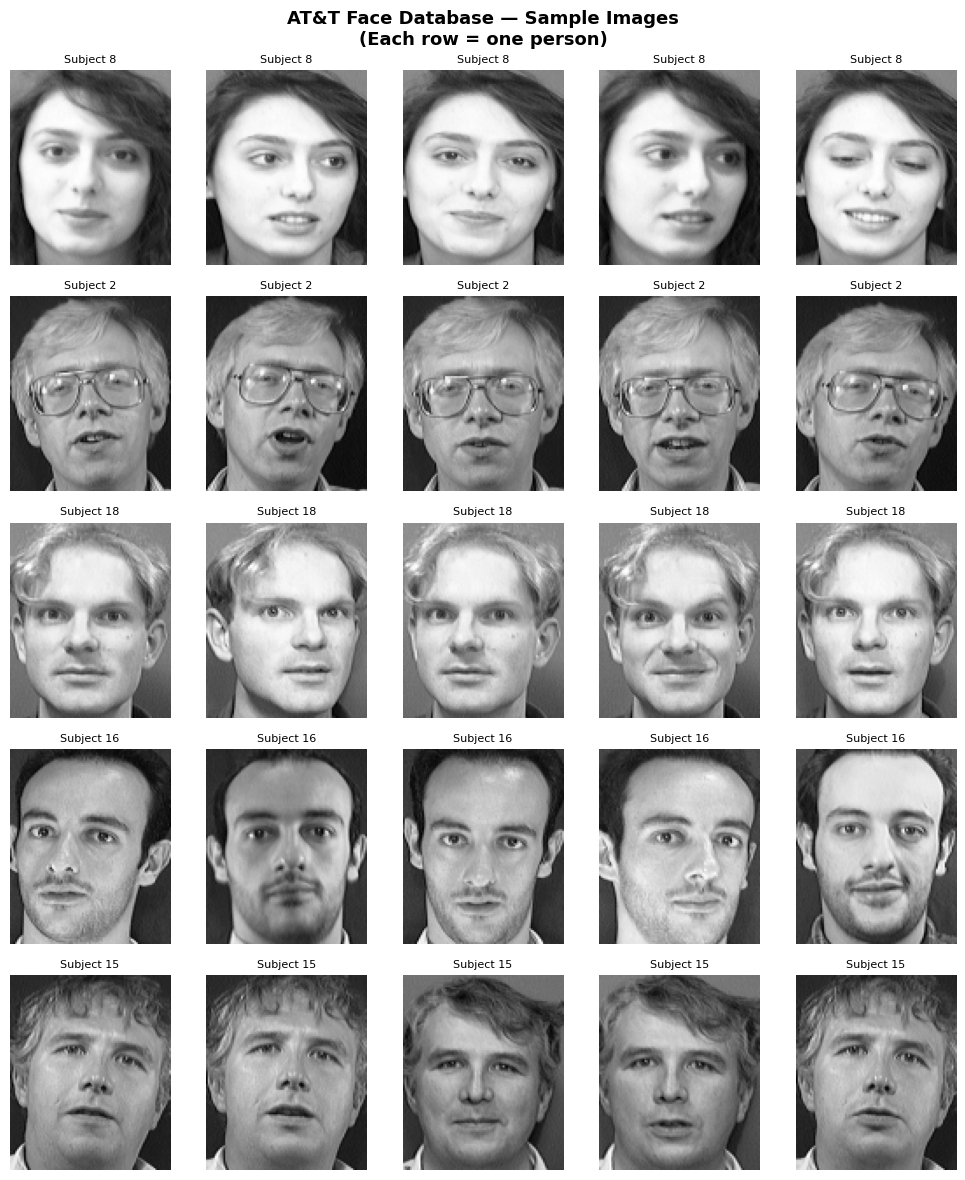

In [ ]:
fig, axes = plt.subplots(5, 5, figsize=(10, 12))
fig.suptitle('AT&T Face Database — Sample Images\n(Each row = one person)',
             fontsize=13, fontweight='bold')

subject_ids = random.sample(range(cfg.NUM_SUBJECTS), 5)

for row, subject_id in enumerate(subject_ids):
    subject_indices = list(np.where(labels == subject_id)[0])
    selected = random.sample(subject_indices, 5)
    for col, img_idx in enumerate(selected):
        ax = axes[row, col]
        ax.imshow(images[img_idx].squeeze(), cmap='gray')
        ax.set_title(f'Subject {subject_id+1}', fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def create_pairs(images, labels, positive_pairs, negative_pairs, seed=42):
    """
    Generate positive (same person) and negative (different person) pairs.
    Labels: 0 = same, 1 = different
    """
    random.seed(seed)
    pair_images_1, pair_images_2, pair_labels = [], [], []
    unique_subjects   = np.unique(labels)
    subject_to_indices = {s: list(np.where(labels == s)[0]) for s in unique_subjects}

    # POSITIVE pairs (same person)
    for subject_id in unique_subjects:
        indices = subject_to_indices[subject_id]
        all_combos = list(itertools.combinations(indices, 2))
        selected   = random.sample(all_combos, min(positive_pairs, len(all_combos)))
        for idx1, idx2 in selected:
            pair_images_1.append(images[idx1])
            pair_images_2.append(images[idx2])
            pair_labels.append(0)  # 0 = same

    # NEGATIVE pairs (different people)
    for subject_id in unique_subjects:
        other_subjects = [s for s in unique_subjects if s != subject_id]
        for _ in range(negative_pairs):
            idx1         = random.choice(subject_to_indices[subject_id])
            other_subject = random.choice(other_subjects)
            idx2         = random.choice(subject_to_indices[other_subject])
            pair_images_1.append(images[idx1])
            pair_images_2.append(images[idx2])
            pair_labels.append(1)  # 1 = different

    # Convert and shuffle
    p1  = np.array(pair_images_1, dtype=np.float32)
    p2  = np.array(pair_images_2, dtype=np.float32)
    lbl = np.array(pair_labels,   dtype=np.float32)
    idx = np.random.permutation(len(lbl))
    return p1[idx], p2[idx], lbl[idx]


print('🔄 Creating pairs...')
img1, img2, pair_labels = create_pairs(
    images, labels,
    cfg.POSITIVE_PAIRS_PER_SUBJECT,
    cfg.NEGATIVE_PAIRS_PER_SUBJECT,
    seed=SEED
)

same = (pair_labels == 0).sum()
diff = (pair_labels == 1).sum()
print(f'\n✅ Pairs created: {len(pair_labels)} total')
print(f'   Positive (same):    {same} ({same/len(pair_labels)*100:.1f}%)')
print(f'   Negative (different): {diff} ({diff/len(pair_labels)*100:.1f}%)')

🔄 Creating pairs...

✅ Pairs created: 1600 total
   Positive (same):    800 (50.0%)
   Negative (different): 800 (50.0%)


In [ ]:
# First split: hold out TEST set
img1_tv, img1_test, img2_tv, img2_test, y_tv, y_test = train_test_split(
    img1, img2, pair_labels,
    test_size=cfg.TEST_SIZE, random_state=SEED, stratify=pair_labels
)

# Second split: separate VALIDATION from training
img1_train, img1_val, img2_train, img2_val, y_train, y_val = train_test_split(
    img1_tv, img2_tv, y_tv,
    test_size=cfg.VALIDATION_SIZE, random_state=SEED, stratify=y_tv
)

print('✅ Data split complete!')
print(f'   Train:      {len(y_train):,} pairs')
print(f'   Validation: {len(y_val):,} pairs')
print(f'   Test:       {len(y_test):,} pairs')

✅ Data split complete!
   Train:      1,156 pairs
   Validation: 204 pairs
   Test:       240 pairs


In [ ]:
def build_encoder(input_shape, embedding_dim):
    """CNN encoder: image → L2-normalized embedding vector."""
    inputs = keras.Input(shape=input_shape, name='encoder_input')

    def conv_block(x, filters, name, dropout=0.2):
        x = layers.Conv2D(filters, (3,3), padding='same', name=f'conv_{name}')(x)
        x = layers.BatchNormalization(name=f'bn_{name}')(x)
        x = layers.Activation('relu', name=f'relu_{name}')(x)
        x = layers.MaxPooling2D((2,2), name=f'pool_{name}')(x)
        x = layers.Dropout(dropout, name=f'drop_{name}')(x)
        return x

    x = conv_block(inputs,  64,  '1', dropout=0.2)
    x = conv_block(x,      128,  '2', dropout=0.2)
    x = conv_block(x,      256,  '3', dropout=0.3)
    x = conv_block(x,      256,  '4', dropout=0.3)

    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(512, name='dense1')(x)
    x = layers.BatchNormalization(name='bn5')(x)
    x = layers.Activation('relu', name='relu5')(x)
    x = layers.Dropout(0.4, name='drop5')(x)
    x = layers.Dense(embedding_dim, name='embedding')(x)

    # L2 normalize: project embeddings onto unit hypersphere
    embeddings = layers.Lambda(
        lambda t: tf.nn.l2_normalize(t, axis=1),
        name='l2_normalize'
    )(x)

    return Model(inputs, embeddings, name='encoder')


input_shape = (cfg.IMG_HEIGHT, cfg.IMG_WIDTH, cfg.IMG_CHANNELS)
encoder     = build_encoder(input_shape, cfg.EMBEDDING_DIM)

print('✅ Encoder built!')
encoder.summary()

✅ Encoder built!


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 112, 92, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 112, 92, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 112, 92, 64)    │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 112, 92, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 56, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 56, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 56, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 56, 46, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 56, 46, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 28, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 28, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 28, 23, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 28, 23, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 28, 23, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 14, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 14, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4 (Conv2D)                 │ (None, 14, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 14, 11, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_4 (Activation)             │ (None, 14, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_4 (MaxPooling2D)           │ (None, 7, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_4 (Dropout)                │ (None, 7, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu5 (Activation)              │ (None, 512)            │             

 Total params: 1,161,856 (4.43 MB)

 Trainable params: 1,159,424 (4.42 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [ ]:
def build_siamese_network(encoder, input_shape):
    """Connect two shared encoders with a distance computation layer."""
    input_a = keras.Input(shape=input_shape, name='input_image_A')
    input_b = keras.Input(shape=input_shape, name='input_image_B')

    # SHARED encoder processes both inputs
    embedding_a = encoder(input_a)
    embedding_b = encoder(input_b)

    # Euclidean distance between embeddings
    distance = layers.Lambda(
        lambda embs: tf.sqrt(
            tf.reduce_sum(tf.square(embs[0] - embs[1]), axis=1, keepdims=True)
        ),
        name='euclidean_distance'
    )([embedding_a, embedding_b])

    return Model(inputs=[input_a, input_b], outputs=distance,
                 name='siamese_network')


siamese_model = build_siamese_network(encoder, input_shape)
print('✅ Siamese Network built!')
siamese_model.summary()

✅ Siamese Network built!


Model: "siamese_network"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image_A       │ (None, 112, 92,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_image_B       │ (None, 112, 92,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ (None, 128)       │  1,161,856 │ input_image_A[0]… │
│ (Functional)        │                   │            │ input_image_B[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ euclidean_distance  │ (None, 1)         │          0 │ encoder[0][0],    │
│ (Lambda)            │                   │            │ encoder[1][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,161,856 (4.43 MB)

 Trainable params: 1,159,424 (4.42 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [ ]:
def contrastive_loss(margin=1.0):
    """Returns contrastive loss function with given margin."""
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        similar_loss    = (1 - y_true) * tf.square(y_pred)
        dissimilar_loss = y_true * tf.square(tf.maximum(0.0, margin - y_pred))
        return tf.reduce_mean(similar_loss + dissimilar_loss) / 2.0
    return loss


def accuracy_with_threshold(threshold=0.5):
    """Accuracy metric: distance > threshold -> different (1), else same (0)."""
    def accuracy(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        preds  = tf.cast(y_pred > threshold, tf.float32)
        return tf.reduce_mean(tf.cast(tf.equal(preds, y_true), tf.float32))
    accuracy.__name__ = f'accuracy_t{threshold}'
    return accuracy


# Compile
siamese_model.compile(
    optimizer=Adam(learning_rate=cfg.LEARNING_RATE),
    loss=contrastive_loss(margin=cfg.MARGIN),
    metrics=[accuracy_with_threshold(threshold=0.5)]
)

print('✅ Model compiled!')
print(f'   Optimizer: Adam  |  LR: {cfg.LEARNING_RATE}')
print(f'   Loss: Contrastive (margin={cfg.MARGIN})')

✅ Model compiled!
   Optimizer: Adam  |  LR: 0.0001
   Loss: Contrastive (margin=1.0)


In [ ]:
import sys
if 'history' in globals():
    print("✅ Training completed! Epochs run:", len(history.history['loss']))
else:
    print("⚠️ Training variable not in globals, checking if siamese_model is compiled...")
    if 'siamese_model' in globals():
        print("Model exists, running fit for 20 epochs...")
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
        ]
        history = siamese_model.fit(
            x=[img1_train, img2_train],
            y=y_train,
            batch_size=cfg.BATCH_SIZE,
            epochs=20,
            validation_data=([img1_val, img2_val], y_val),
            callbacks=callbacks,
            shuffle=True,
            verbose=1
        )
        print("✅ Training complete! Epochs run:", len(history.history['loss']))


✅ Training completed! Epochs run: 25


📊 Evaluating on Test Set...


1/8 ━━━━━━━━━━━━━━━━━━━━ 6s 862ms/step

3/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step 

5/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 218ms/step


Optimal threshold: 0.080
Test accuracy:     0.8000 (80.00%)

               precision    recall  f1-score   support

     Same (0)       0.83      0.76      0.79       120
Different (1)       0.78      0.84      0.81       120

     accuracy                           0.80       240
    macro avg       0.80      0.80      0.80       240
 weighted avg       0.80      0.80      0.80       240



✅ Saved confusion_matrix_siamese.png
✅ Saved encoder_model.h5 and siamese_model.h5


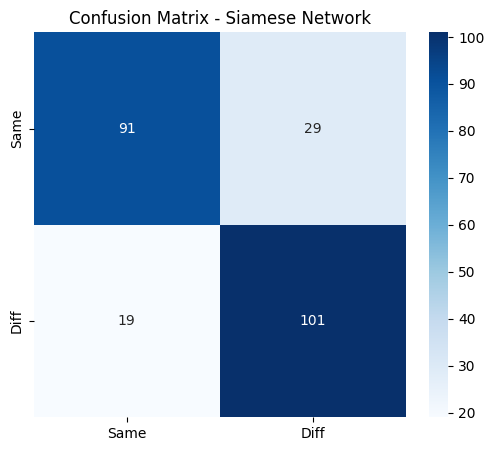

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.manifold import TSNE
import random

print("📊 Evaluating on Test Set...")
distances = siamese_model.predict([img1_test, img2_test], batch_size=cfg.BATCH_SIZE).squeeze()

thresholds = np.arange(0.0, 2.0, 0.01)
best_thresh = 0.5
best_acc = 0.0
for t in thresholds:
    preds = (distances > t).astype(int)
    acc = (preds == y_test.astype(int)).mean()
    if acc > best_acc:
        best_acc, best_thresh = acc, t

predictions = (distances > best_thresh).astype(int)
true_labels = y_test.astype(int)

print(f'Optimal threshold: {best_thresh:.3f}')
print(f'Test accuracy:     {best_acc:.4f} ({best_acc*100:.2f}%)')
print('\n' + '='*50)
print(classification_report(true_labels, predictions, target_names=['Same (0)', 'Different (1)']))

# Save Confusion Matrix
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Same', 'Diff'], yticklabels=['Same', 'Diff'])
plt.title('Confusion Matrix - Siamese Network')
plt.savefig('confusion_matrix_siamese.png')
print("✅ Saved confusion_matrix_siamese.png")

# Save Embeddings & Models
encoder.save('./encoder_model.h5')
siamese_model.save('./siamese_model.h5')
print("✅ Saved encoder_model.h5 and siamese_model.h5")
